In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import f2D_utilities as utils;
from matplotlib.animation import FuncAnimation;

# Styling.
plt.style.use("ggplot");

In [ ]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_8.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5";
delta_t = reader.fetch_delta_t(directory_path);
data_arrays = reader.fetch_f2D_data(directory_path);

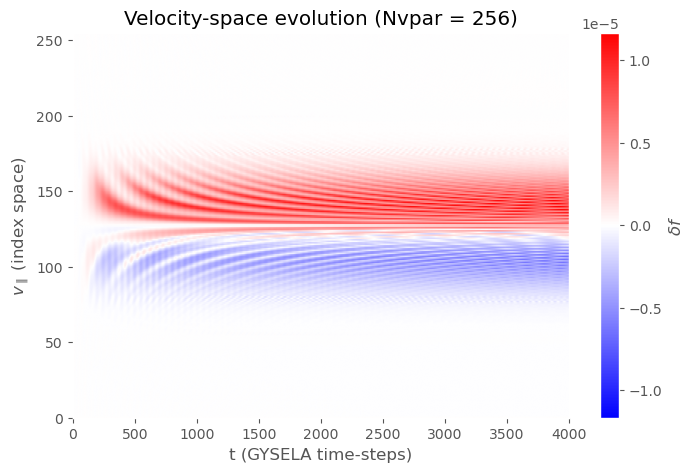

In [3]:
def compute_delta_f_vpar(f2D_list):
	# Convert from f(r, vpar) to delta_f(vpar).
	maxwellian = f2D_list[0];
	delta_f_vpar_time = [];
	
	for perturbed_distribution in f2D_list:

		delta_f = perturbed_distribution - maxwellian;
		delta_f_v = delta_f.mean(dim="r");
		delta_f_vpar_time.append(delta_f_v.values);
	
	delta_f_vpar_time = np.array(delta_f_vpar_time);
	vpar = f2D_list[0]["vpar"].values;
	return vpar, delta_f_vpar_time;

def calculate_stride(delta_t, dt_diag):

	# The logic is this: for a dt_diag of 50, and a delta_t of 25, we have a stride of 2.
	# Stride is also the diagnostic interval; for every two simulation time-steps (50 code units), we have one Phi2D sample.
	# This still retains the normalisation interred within GYSELA itself.
	return dt_diag / delta_t;

def plot_velocity_evolution(f2D_list, dt_diag, delta_t):

	vpar, delta_f_vpar_time = compute_delta_f_vpar(f2D_list);
	stride = calculate_stride(delta_t, dt_diag);
	time_range = np.arange(len(delta_f_vpar_time)) * stride;
	
	plt.figure(figsize=(8, 5));
	plt.imshow(
		delta_f_vpar_time.T,
		aspect = "auto",
		origin = "lower",
		extent = [time_range[0], time_range[-1], vpar[0], vpar[-1]],
		cmap="bwr",
		vmin=-np.max(np.abs(delta_f_vpar_time)),
		vmax= np.max(np.abs(delta_f_vpar_time)),
	);
	plt.title("Velocity-space evolution (Nvpar = 256)");
	plt.xlabel("t (GYSELA time-steps)");
	plt.ylabel(r"$v_\parallel$ (index space)");
	plt.colorbar(label = r"$\delta f$");
	plt.grid(False);
	plt.show();

plot_velocity_evolution(data_arrays, dt_diag = 50, delta_t = delta_t);